# Datenanalyse mit SQL & Python - Tag 2: Joins, HAVING, Subqueries und CTEs

**Thema:** Shop-Daten mit mehreren Tabellen analysieren  
**Datensatz:** `shop_orders`, `shop_customers`, `shop_products`  
**Ziel:** Tag-1-SQL wiederholen und Schritt für Schritt zu Joins, `HAVING`, Unterabfragen und CTEs erweitern.


## Ablauf und Zeitplan

| Zeit | Kursphase | Inhalt |
|---|---|---|
| 09:00-09:30 | Wiederholung | Übung: `SELECT`, `FROM`, `WHERE`, `ORDER BY`, `COUNT`, `SUM`, `AVG`, `MAX` |
| 09:30-10:30 | `GROUP BY`, `HAVING` & `JOINS` | `GROUP BY` & `HAVING`, `JOINS` & Star-Schema |
| 10:30-11:30 | Subqueries & Datenmodellierung | Subqueries in `WHERE` / `FROM`, Primärschlüssel & Fremdschlüssel, Grundidee von relationalen Modellen und Star-Schema-Logik |
| 11:30-12:10 | Mittagspause | - |
| 12:10-14:00 | Erweiterte SQL-Konzepte & Übung | Common Table Expressions (`CTE`), Window Functions, z. B. Ranking und laufende Summen |
| 14:00-14:20 | Pause | - |
| 14:20-15:40 | Praktische Übung | Mini-Projekt & Präsentation vorbereiten |
| 15:40-16:00 | Ergebnisse & Diskussion | Präsentation, Reflexion, Q&A |

**Hinweis zur Zeitplanung:** Die Zeiten sind Richtwerte. Wenn eine Diskussion besonders hilfreich ist, kann ein Block leicht angepasst werden.


## Lernziele

Nach Tag 2 kannst du:

- `GROUP BY` aus Tag 1 sicher wiederholen
- `WHERE` und `HAVING` unterscheiden
- Bestellungen mit Kundendaten per `JOIN` verbinden
- mehrere Tabellen kombinieren, um fachliche Kennzahlen zu berechnen
- einfache Unterabfragen lesen und schreiben
- einfache CTEs mit `WITH` verwenden und mit Unterabfragen vergleichen
- einfache Window Functions wie `ROW_NUMBER`, `RANK` und laufende Summen einsetzen


## Datenmodell: Shop

Wir arbeiten mit drei Tabellen:

| Tabelle | Inhalt | Wichtige Spalten |
|---|---|---|
| `orders` | Bestellungen | `order_id`, `customer_id`, `product_id`, `quantity` |
| `customers` | Kundinnen und Kunden | `customer_id`, `name`, `city` |
| `products` | Produkte | `product_id`, `product_name`, `category`, `price` |

Beziehungen:

- `orders.customer_id` verweist auf `customers.customer_id`
- `orders.product_id` verweist auf `products.product_id`


## Einrichtung & Daten laden

Diese Zelle lädt die Shop-Daten und erstellt daraus eine SQLite-Datenbank im Arbeitsspeicher.


In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

SHOP_DIR = 'https://raw.githubusercontent.com/chiaoya/Data_to_Decision_with_SQL_Python/refs/heads/main/course_data/shop/'

orders_df = pd.read_csv(SHOP_DIR + 'shop_orders.csv')
customers_df = pd.read_csv(SHOP_DIR + 'shop_customers.csv')
products_df = pd.read_csv(SHOP_DIR + 'shop_products.csv')

conn = sqlite3.connect(':memory:')
orders_df.to_sql('orders', conn, index=False, if_exists='replace')
customers_df.to_sql('customers', conn, index=False, if_exists='replace')
products_df.to_sql('products', conn, index=False, if_exists='replace')

print('Geladene Tabellen:')
print('orders:   ', orders_df.shape)
print('customers:', customers_df.shape)
print('products: ', products_df.shape)


Geladene Tabellen:
orders:    (50, 4)
customers: (20, 3)
products:  (20, 4)


# 09:30–10:30 | GROUP BY, HAVING & JOINs

## 1. Warm-up: Orders-Tabelle verstehen

Wir starten nur mit `orders`. Das wiederholt Tag 1 und zeigt gleichzeitig, warum wir später Joins brauchen.


In [2]:
query = '''
SELECT *
FROM orders;
'''

pd.read_sql_query(query, conn).head(10)


,order_id,customer_id,product_id,quantity
0,1001,14,120,4
1,1002,20,110,3
2,1003,4,105,4
3,1004,12,101,4
4,1005,19,108,3
5,1006,2,107,2
6,1007,8,110,2
7,1008,2,111,4
8,1009,17,108,2
9,1010,13,105,1


### Wiederholung: GROUP BY

Frage: Wie viele Bestellungen gibt es pro Kundin oder Kunde?


In [3]:
query = '''
SELECT
    customer_id,
    COUNT(*) AS anzahl_bestellungen
FROM orders
GROUP BY customer_id
ORDER BY anzahl_bestellungen DESC;
'''

pd.read_sql_query(query, conn).head(10)


,customer_id,anzahl_bestellungen
0,13,6
1,20,4
2,10,4
3,7,4
4,4,4
5,19,3
6,16,3
7,8,3
8,5,3
9,2,3


### Wiederholung: Aggregation mit SUM

Frage: Wie viele Artikel wurden pro Kundin oder Kunde insgesamt bestellt?


In [4]:
query = '''
SELECT
    customer_id,
    SUM(quantity) AS gesamtmenge
FROM orders
GROUP BY customer_id
ORDER BY gesamtmenge DESC;
'''

pd.read_sql_query(query, conn).head(10)


,customer_id,gesamtmenge
0,4,15
1,13,13
2,10,13
3,2,10
4,20,9
5,19,8
6,15,7
7,7,7
8,16,6
9,8,6


## 2. WHERE vs. HAVING

`WHERE` filtert einzelne Zeilen **vor** der Gruppierung.  
`HAVING` filtert Gruppen **nach** der Gruppierung.


### WHERE: Zeilen vor der Gruppierung filtern

Frage: Welche Kundinnen und Kunden haben Bestellungen mit mehr als 3 Artikeln aufgegeben?


In [5]:
query = '''
SELECT
    customer_id,
    COUNT(*) AS anzahl_grosser_bestellungen
FROM orders
WHERE quantity > 3
GROUP BY customer_id
ORDER BY anzahl_grosser_bestellungen DESC;
'''

pd.read_sql_query(query, conn).head(10)


,customer_id,anzahl_grosser_bestellungen
0,10,3
1,4,3
2,13,2
3,2,2
4,15,1
5,14,1
6,12,1


### HAVING: Gruppen nach der Aggregation filtern

Frage: Welche Kundinnen und Kunden haben insgesamt mehr als 8 Artikel bestellt?


In [6]:
query = '''
SELECT
    customer_id,
    SUM(quantity) AS gesamtmenge
FROM orders
GROUP BY customer_id
HAVING SUM(quantity) > 8
ORDER BY gesamtmenge DESC;
'''

pd.read_sql_query(query, conn)


,customer_id,gesamtmenge
0,4,15
1,13,13
2,10,13
3,2,10
4,20,9


### Vergleich

- `WHERE quantity > 3`: betrachtet einzelne Bestellzeilen.
- `HAVING SUM(quantity) > 8`: betrachtet das Ergebnis pro Gruppe.

Das ist ein wichtiger Denkwechsel: Erst Zeilen, dann Gruppen.


## 3. JOIN: Orders mit Customers verbinden

Die `orders`-Tabelle enthält nur IDs. Mit einem Join werden daraus verständliche Kundendaten.


In [8]:
query = '''
SELECT
    o.order_id,
    c.name,
    c.city,
    o.product_id,
    o.quantity
FROM orders AS o
INNER JOIN customers AS c
    ON o.customer_id = c.customer_id
ORDER BY o.order_id;
'''

pd.read_sql_query(query, conn).head(10)


,order_id,name,city,product_id,quantity
0,1001,Customer_14,Hamburg,120,4
1,1002,Customer_20,Cologne,110,3
2,1003,Customer_4,Berlin,105,4
3,1004,Customer_12,Berlin,101,4
4,1005,Customer_19,Cologne,108,3
5,1006,Customer_2,Cologne,107,2
6,1007,Customer_8,Berlin,110,2
7,1008,Customer_2,Cologne,111,4
8,1009,Customer_17,Berlin,108,2
9,1010,Customer_13,Berlin,105,1


### JOIN plus Tag-1-Konzepte

Frage: Wie viele Bestellungen und Artikel gibt es pro Stadt?


In [9]:
query = '''
SELECT
    c.city,
    COUNT(o.order_id) AS anzahl_bestellungen,
    SUM(o.quantity) AS gesamtmenge
FROM orders AS o
INNER JOIN customers AS c
    ON o.customer_id = c.customer_id
GROUP BY c.city
ORDER BY gesamtmenge DESC;
'''

pd.read_sql_query(query, conn)


,city,anzahl_bestellungen,gesamtmenge
0,Berlin,25,66
1,Cologne,16,38
2,Hamburg,5,12
3,Munich,4,9


## 4. Drei Tabellen kombinieren

Für Umsatz brauchen wir zusätzlich den Produktpreis aus `products`.


In [10]:
query = '''
SELECT
    o.order_id,
    c.name,
    c.city,
    p.product_name,
    p.category,
    o.quantity,
    p.price,
    o.quantity * p.price AS revenue
FROM orders AS o
INNER JOIN customers AS c
    ON o.customer_id = c.customer_id
INNER JOIN products AS p
    ON o.product_id = p.product_id
ORDER BY o.order_id;
'''

pd.read_sql_query(query, conn).head(10)


,order_id,name,city,product_name,category,quantity,price,revenue
0,1001,Customer_14,Hamburg,Product_20,Sports,4,33,132
1,1002,Customer_20,Cologne,Product_10,Sports,3,50,150
2,1003,Customer_4,Berlin,Product_5,Home,4,13,52
3,1004,Customer_12,Berlin,Product_1,Sports,4,137,548
4,1005,Customer_19,Cologne,Product_8,Sports,3,146,438
5,1006,Customer_2,Cologne,Product_7,Sports,2,101,202
6,1007,Customer_8,Berlin,Product_10,Sports,2,50,100
7,1008,Customer_2,Cologne,Product_11,Home,4,154,616
8,1009,Customer_17,Berlin,Product_8,Sports,2,146,292
9,1010,Customer_13,Berlin,Product_5,Home,1,13,13


### Umsatz pro Kategorie

Hier verbinden wir Joins mit `GROUP BY`, `SUM` und `ORDER BY`.


In [11]:
query = '''
SELECT
    p.category,
    SUM(o.quantity * p.price) AS revenue
FROM orders AS o
INNER JOIN products AS p
    ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY revenue DESC;
'''

pd.read_sql_query(query, conn)


,category,revenue
0,Sports,5459
1,Fashion,2162
2,Home,1938
3,Electronics,557


# 10:30–11:30 | Subqueries & CTEs

## 5. Unterabfrage

Eine Unterabfrage ist eine Abfrage innerhalb einer anderen Abfrage.

Frage: Welche Kundinnen und Kunden haben mehr Artikel bestellt als der Durchschnitt pro Kundin oder Kunde?


In [12]:
query = '''
SELECT
    customer_id,
    SUM(quantity) AS gesamtmenge
FROM orders
GROUP BY customer_id
HAVING SUM(quantity) > (
    SELECT AVG(kundenmenge)
    FROM (
        SELECT SUM(quantity) AS kundenmenge
        FROM orders
        GROUP BY customer_id
    )
)
ORDER BY gesamtmenge DESC;
'''

pd.read_sql_query(query, conn)


,customer_id,gesamtmenge
0,4,15
1,13,13
2,10,13
3,2,10
4,20,9
5,19,8
6,15,7
7,7,7


## 6. CTE mit WITH

Eine CTE macht Zwischenergebnisse lesbarer. Die Logik ist ähnlich wie bei der Unterabfrage, aber oft leichter zu erklären und zu debuggen.


In [13]:
query = '''
WITH customer_totals AS (
    SELECT
        customer_id,
        SUM(quantity) AS gesamtmenge
    FROM orders
    GROUP BY customer_id
),
average_total AS (
    SELECT AVG(gesamtmenge) AS durchschnitt
    FROM customer_totals
)
SELECT
    ct.customer_id,
    ct.gesamtmenge
FROM customer_totals AS ct
CROSS JOIN average_total AS avg_t
WHERE ct.gesamtmenge > avg_t.durchschnitt
ORDER BY ct.gesamtmenge DESC;
'''

pd.read_sql_query(query, conn)


,customer_id,gesamtmenge
0,4,15
1,10,13
2,13,13
3,2,10
4,20,9
5,19,8
6,7,7
7,15,7


### Subquery vs. CTE

Beide Varianten beantworten dieselbe Frage.

- Unterabfragen sind kompakt.
- CTEs sind oft lesbarer, wenn mehrere Zwischenschritte nötig sind.
- Für Unterricht und Teamarbeit sind CTEs häufig leichter zu diskutieren.


# 11:30–12:10 | 🍽️ Mittagspause

# 12:10–14:00 | Window Functions

## 7. Window Functions

Window Functions berechnen Werte über eine Gruppe von Zeilen, ohne die Detailzeilen zu verlieren.  
Der Unterschied zu `GROUP BY`: Die Zeilen bleiben sichtbar, und die Kennzahl wird als zusätzliche Spalte ergänzt.

Typische Muster:

- `ROW_NUMBER()` nummeriert Zeilen innerhalb einer Gruppe.
- `RANK()` erstellt Rankings, z. B. Top-Produkte nach Umsatz.
- `SUM(...) OVER (...)` berechnet laufende Summen.
- `AVG(...) OVER (...)` ergänzt Vergleichswerte pro Gruppe.


### Beispiel 1: Bestell-Reihenfolge pro Kunde

Frage: In welcher Reihenfolge haben Kundinnen und Kunden ihre Bestellungen aufgegeben?

`ROW_NUMBER()` startet fuer jede Kundin bzw. jeden Kunden neu, weil wir `PARTITION BY customer_id` verwenden.


In [ ]:
query = '''
SELECT
    o.customer_id,
    c.name,
    o.order_id,
    o.product_id,
    o.quantity,
    ROW_NUMBER() OVER (
        PARTITION BY o.customer_id
        ORDER BY o.order_id
    ) AS order_number_for_customer
FROM orders AS o
INNER JOIN customers AS c
    ON o.customer_id = c.customer_id
ORDER BY o.customer_id, order_number_for_customer;
'''

pd.read_sql_query(query, conn).head(15)


### Beispiel 2: Produkte nach Umsatz ranken

Frage: Welche Produkte bringen den meisten Umsatz?

`RANK()` sortiert die Produkte nach Umsatz. Bei gleichen Werten bekommen Produkte denselben Rang.


In [ ]:
query = '''
WITH product_revenue AS (
    SELECT
        p.product_id,
        p.product_name,
        p.category,
        SUM(o.quantity * p.price) AS revenue
    FROM orders AS o
    INNER JOIN products AS p
        ON o.product_id = p.product_id
    GROUP BY p.product_id, p.product_name, p.category
)
SELECT
    product_id,
    product_name,
    category,
    revenue,
    RANK() OVER (ORDER BY revenue DESC) AS revenue_rank
FROM product_revenue
ORDER BY revenue_rank;
'''

pd.read_sql_query(query, conn).head(10)


### Beispiel 3: Laufender Umsatz pro Kunde

Frage: Wie entwickelt sich der kumulierte Umsatz pro Kundin oder Kunde ueber die Bestellungen hinweg?

Die Window Function summiert alle bisherigen Bestellungen innerhalb derselben Kundin bzw. desselben Kunden.


In [ ]:
query = '''
SELECT
    o.customer_id,
    c.name,
    o.order_id,
    p.product_name,
    o.quantity,
    p.price,
    o.quantity * p.price AS order_value,
    SUM(o.quantity * p.price) OVER (
        PARTITION BY o.customer_id
        ORDER BY o.order_id
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS running_customer_revenue
FROM orders AS o
INNER JOIN customers AS c
    ON o.customer_id = c.customer_id
INNER JOIN products AS p
    ON o.product_id = p.product_id
ORDER BY o.customer_id, o.order_id;
'''

pd.read_sql_query(query, conn).head(15)


### Beispiel 4: Produktumsatz mit Kategorie-Durchschnitt vergleichen

Frage: Liegt ein Produkt ueber oder unter dem durchschnittlichen Umsatz seiner Kategorie?

Hier bleibt jedes Produkt sichtbar. `AVG(revenue) OVER (PARTITION BY category)` fuegt den Kategorie-Durchschnitt als Vergleichsspalte hinzu.


In [ ]:
query = '''
WITH product_revenue AS (
    SELECT
        p.product_id,
        p.product_name,
        p.category,
        SUM(o.quantity * p.price) AS revenue
    FROM orders AS o
    INNER JOIN products AS p
        ON o.product_id = p.product_id
    GROUP BY p.product_id, p.product_name, p.category
)
SELECT
    product_name,
    category,
    revenue,
    ROUND(AVG(revenue) OVER (PARTITION BY category), 2) AS avg_category_revenue,
    ROUND(revenue - AVG(revenue) OVER (PARTITION BY category), 2) AS difference_to_category_avg
FROM product_revenue
ORDER BY category, revenue DESC;
'''

pd.read_sql_query(query, conn)


### Zusatzblock: Weitere Window Functions und Datumslogik

Nach Beispiel 4 lohnt sich ein kurzer Transferblock mit kleinen, kuenstlichen Tabellen. Dadurch sieht man die Logik ohne Ablenkung durch das groessere Shop-Datenmodell.

**Zeitplanung fuer neues Material: ca. 38-46 Minuten**

| Teil | Inhalt | Geschaetzte Zeit |
|---|---:|---:|
| Beispiel 5 | `RANK()` vs. `DENSE_RANK()` mit gleicher Punktzahl | 8-10 Min. |
| Kurzaufgabe 5a | Rangfolge vorhersagen und erklaeren | 4-5 Min. |
| Beispiel 6 | Datumsspalte: Jahr, Monat, Monatsaggregation | 9-11 Min. |
| Kurzaufgabe 6a | Umsatz pro Monat interpretieren | 4-5 Min. |
| Beispiel 7 | `LAG()` und `LEAD()` fuer vorherige/naechste Bestellung | 10-12 Min. |
| Kurzaufgabe 7a | Differenz zum vorherigen Umsatz formulieren | 3-4 Min. |


### Beispiel 5: `RANK()` vs. `DENSE_RANK()`

Frage: Was passiert bei gleichen Werten im Ranking?

- `RANK()` laesst nach Gleichstand eine Luecke.
- `DENSE_RANK()` zaehlt ohne Luecke weiter.
- `ROW_NUMBER()` vergibt immer eindeutige Zeilennummern, auch bei Gleichstand.

**Mini-Aufgabe vor dem Ausfuehren (ca. 2 Min.):** Welche Rangnummer bekommt `Smartwatch`, wenn `Laptop` und `Tablet` beide 1200 Umsatz haben?


In [1]:
query = '''
WITH product_scores(product_name, category, revenue) AS (
    VALUES
        ('Laptop', 'Electronics', 1200),
        ('Tablet', 'Electronics', 1200),
        ('Smartwatch', 'Electronics', 900),
        ('Desk Chair', 'Office', 700),
        ('Notebook Set', 'Office', 700),
        ('Pen Set', 'Office', 300)
)
SELECT
    product_name,
    category,
    revenue,
    ROW_NUMBER() OVER (ORDER BY revenue DESC) AS row_number_revenue,
    RANK() OVER (ORDER BY revenue DESC) AS rank_revenue,
    DENSE_RANK() OVER (ORDER BY revenue DESC) AS dense_rank_revenue
FROM product_scores
ORDER BY revenue DESC, product_name;
'''

pd.read_sql_query(query, conn)


NameError: name 'pd' is not defined

**Kurzaufgabe 5a (ca. 4-5 Min.)**

1. Warum hat `Smartwatch` bei `RANK()` nicht Rang 2?
2. Welche Funktion ist besser, wenn ihr Top-3-Gruppen ohne Luecken zeigen wollt?
3. Aendert die Sortierung auf `ORDER BY category, revenue DESC`: Was passiert mit dem Ranking?


### Beispiel 6: Datumsspalten zerlegen - Jahr und Monat

Viele echte Analysen brauchen eine Zeitlogik. In SQLite nutzt man dafuer haeufig `strftime()`:

- `strftime('%Y', order_date)` extrahiert das Jahr.
- `strftime('%m', order_date)` extrahiert den Monat.
- `date(order_date, '+7 days')` verschiebt ein Datum um 7 Tage.


In [ ]:
query = '''
WITH dated_orders(order_id, customer, order_date, revenue) AS (
    VALUES
        (1, 'Anna', '2026-01-05', 120),
        (2, 'Ben',  '2026-01-18', 90),
        (3, 'Anna', '2026-02-02', 150),
        (4, 'Cara', '2026-02-14', 220),
        (5, 'Ben',  '2026-03-03', 130),
        (6, 'Anna', '2026-03-20', 80)
)
SELECT
    order_id,
    customer,
    order_date,
    strftime('%Y', order_date) AS order_year,
    strftime('%m', order_date) AS order_month,
    date(order_date, '+7 days') AS follow_up_date,
    revenue
FROM dated_orders
ORDER BY order_date;
'''

pd.read_sql_query(query, conn)


**Kurzaufgabe 6a (ca. 4-5 Min.)**

Berechnet aus derselben Mini-Tabelle den Umsatz pro Monat. Welche Monate sind staerker, und welche Einschraenkung hat diese Aussage bei nur sechs Bestellungen?


In [ ]:
query = '''
WITH dated_orders(order_id, customer, order_date, revenue) AS (
    VALUES
        (1, 'Anna', '2026-01-05', 120),
        (2, 'Ben',  '2026-01-18', 90),
        (3, 'Anna', '2026-02-02', 150),
        (4, 'Cara', '2026-02-14', 220),
        (5, 'Ben',  '2026-03-03', 130),
        (6, 'Anna', '2026-03-20', 80)
)
SELECT
    strftime('%Y-%m', order_date) AS order_month,
    SUM(revenue) AS monthly_revenue,
    COUNT(*) AS order_count
FROM dated_orders
GROUP BY strftime('%Y-%m', order_date)
ORDER BY order_month;
'''

pd.read_sql_query(query, conn)


### Beispiel 7: `LAG()` und `LEAD()` - vorherige und nächste Zeile

Frage: Wie verändert sich der Umsatz im Vergleich zur vorherigen Bestellung derselben Kundin bzw. desselben Kunden?

- `LAG(revenue)` schaut eine Zeile zurueck.
- `LEAD(revenue)` schaut eine Zeile nach vorne.
- Wichtig ist die Reihenfolge im Window: hier `ORDER BY order_date`.


In [ ]:
query = '''
WITH dated_orders(order_id, customer, order_date, revenue) AS (
    VALUES
        (1, 'Anna', '2026-01-05', 120),
        (2, 'Ben',  '2026-01-18', 90),
        (3, 'Anna', '2026-02-02', 150),
        (4, 'Cara', '2026-02-14', 220),
        (5, 'Ben',  '2026-03-03', 130),
        (6, 'Anna', '2026-03-20', 80)
)
SELECT
    customer,
    order_date,
    revenue,
    LAG(revenue) OVER (
        PARTITION BY customer
        ORDER BY order_date
    ) AS previous_revenue,
    revenue - LAG(revenue) OVER (
        PARTITION BY customer
        ORDER BY order_date
    ) AS difference_to_previous,
    LEAD(revenue) OVER (
        PARTITION BY customer
        ORDER BY order_date
    ) AS next_revenue
FROM dated_orders
ORDER BY customer, order_date;
'''

pd.read_sql_query(query, conn)


**Kurzaufgabe 7a (ca. 3-4 Min.)**

1. Warum ist `previous_revenue` bei der ersten Bestellung pro Kundin bzw. Kunde leer?
2. Bei welcher Person steigt der Umsatz gegenueber der vorherigen Bestellung?
3. Formuliert einen Mini-Insight im S-C-R-Stil: `S: ...`, `C: ...`, `R: ...`.

S-C-R bedeutet:

- `S = So what?` Was ist die wichtige Veraenderung oder Beobachtung?
- `C = Context` Verglichen womit wird diese Beobachtung relevant?
- `R = Recommendation` Welche konkrete Handlung empfehlt ihr daraus?

Beispiel:

- `S:` Annas Umsatz steigt von 120 auf 150 Euro.
- `C:` Das ist ein Plus von 30 Euro gegenueber ihrer vorherigen Buchung.
- `R:` Das Fitness-Team koennte aehnliche Mitglieder mit Follow-up-Angeboten oder Kurs-Bundles ansprechen.


### Zwischenfazit Window Functions

Window Functions sind besonders nuetzlich, wenn ihr Detailzeilen behalten wollt und trotzdem Vergleichswerte braucht:

- Ranking: `ROW_NUMBER()`, `RANK()`, `DENSE_RANK()`
- Vergleich zur Gruppe: `AVG(...) OVER (PARTITION BY ...)`
- Laufende Werte: `SUM(...) OVER (ORDER BY ...)`
- Vorher/Nachher-Vergleich: `LAG()`, `LEAD()`
- Zeitlogik: Jahr/Monat zuerst aus Datumsspalten ableiten, danach aggregieren oder mit Windows vergleichen


# 14:00–14:20 | ☕ Pause

# 14:20–15:40 | Mini-Visualisierung & Praxis mit Day_2_Exercise_Teil B

## 8. Mini-Visualisierung

Zum Abschluss visualisieren wir den Umsatz pro Produktkategorie.


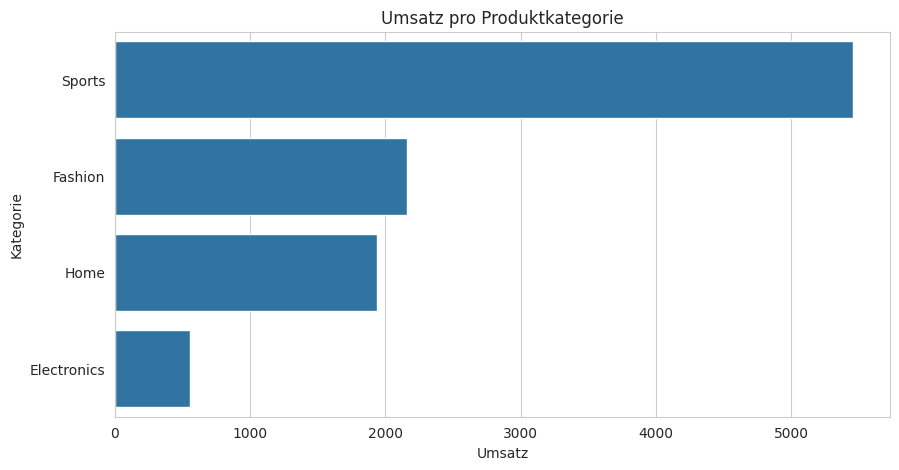

In [14]:
query = '''
SELECT
    p.category,
    SUM(o.quantity * p.price) AS revenue
FROM orders AS o
INNER JOIN products AS p
    ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY revenue DESC;
'''

category_revenue = pd.read_sql_query(query, conn)

sns.barplot(data=category_revenue, x='revenue', y='category')
plt.title('Umsatz pro Produktkategorie')
plt.xlabel('Umsatz')
plt.ylabel('Kategorie')
plt.show()


# 15:40–16:00 | Zusammenfassung & Diskussion

## Zusammenfassung

Heute hast du Tag-1-Grundlagen erweitert:

- `GROUP BY` beantwortet Fragen pro Gruppe.
- `HAVING` filtert aggregierte Gruppen.
- `JOIN` verbindet IDs mit Bedeutung.
- Subqueries und CTEs helfen bei mehrstufigen Analysefragen.
- Window Functions berechnen Rankings, laufende Summen und Vergleichswerte, ohne Zeilen zusammenzufassen.
